📊 KEY DESCRIPTIVE STATISTICS
----------------------------------------
                       mean      std      min      50%       max    range
Years_At_Company       5.23     2.73     0.50     5.30     10.00     9.50
Monthly_Salary_USD  7409.74  1400.75  4204.49  7411.24  10930.64  6726.15
Overtime_Hours_Mth    19.65     9.78     1.00    18.00     60.00    59.00
Performance_Score      3.78     0.58     2.00     3.80      5.00     3.00
Satisfaction_Score     8.06     1.02     4.90     8.20     10.00     5.10


🏢 EMPLOYEE COUNT BY DEPARTMENT
----------------------------------------
Department
Engineering    334
Sales          318
Operations     253
Marketing      186
HR             109
Name: count, dtype: int64


🔗 CORRELATION MATRIX MATRIX DETECTED
----------------------------------------
                    Years_At_Company  Monthly_Salary_USD  Overtime_Hours_Mth  \
Years_At_Company               1.000               0.692              -0.004   
Monthly_Salary_USD             0.692    

/tmp/ipykernel_14566/180068455.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Satisfaction_Score', palette='Set2', ax=axes[0,1])


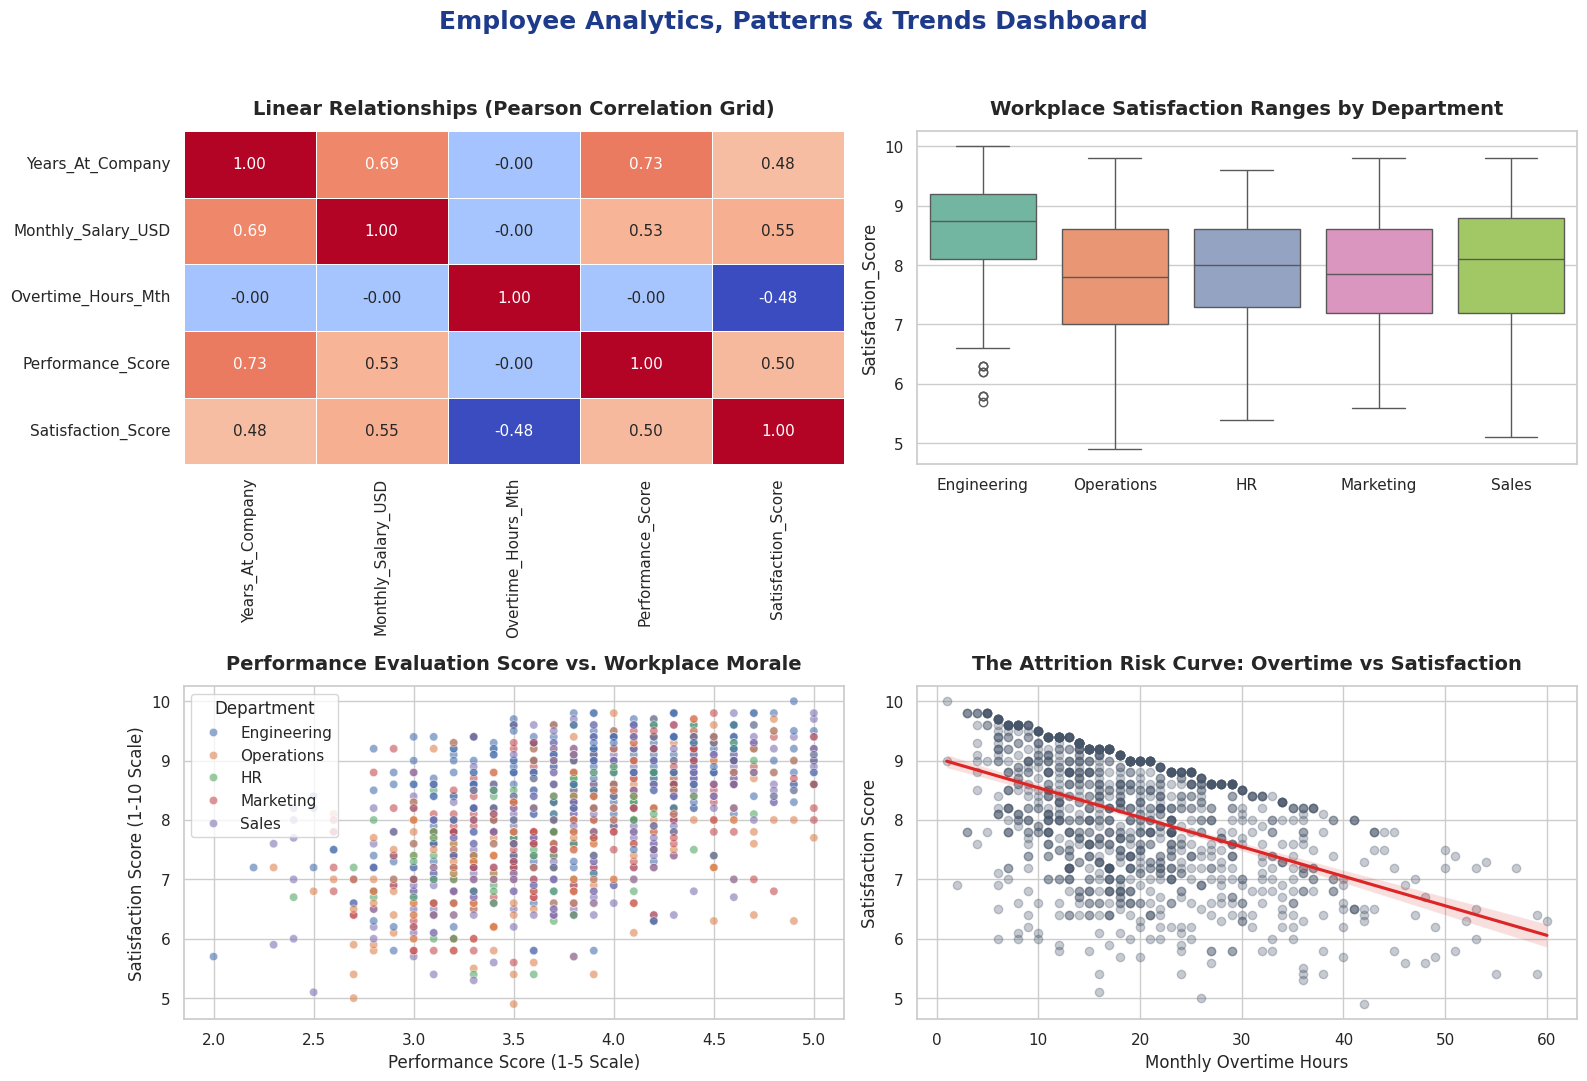

🎉 Analysis Complete! Visual report layout exported as 'data_trends_dashboard.png'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme for charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

def analyze_dataset(file_path):
    
    df = pd.read_csv(file_path)
    
    print("📊 KEY DESCRIPTIVE STATISTICS")
    print("-" * 40)
    summary_stats = df.describe().T
    # Adding range to the summary for clearer perspective
    summary_stats['range'] = summary_stats['max'] - summary_stats['min']
    print(summary_stats[['mean', 'std', 'min', '50%', 'max', 'range']].round(2))
    print("\n")
    
    # 3. Categorical Distributions
    print("🏢 EMPLOYEE COUNT BY DEPARTMENT")
    print("-" * 40)
    print(df['Department'].value_counts())
    print("\n")

    # 4. Correlation Analysis
    print("🔗 CORRELATION MATRIX MATRIX DETECTED")
    print("-" * 40)
    # Exclude non-numeric values for calculation
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()
    print(corr_matrix.round(3))
    print("\n")
    
    # Identify key influencing factors for Satisfaction
    print("🎯 STRONGEST INFLUENCERS ON EMPLOYEE SATISFACTION")
    print("-" * 40)
    satisfaction_corrs = corr_matrix['Satisfaction_Score'].sort_values(ascending=False)
    for index, value in satisfaction_corrs.items():
        if index != 'Satisfaction_Score':
            relationship = "Positive" if value > 0 else "Negative"
            print(f" -> {index:<22}: {value:>6.2f} ({relationship} Impact)")
    print("\n")

    # 5. DATA VISUALIZATION ENGINE
    print("🎨 GENERATING STRUCTURED VISUAL REPORT...")
    
    # Create an interactive multi-panel dashboard
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('Employee Analytics, Patterns & Trends Dashboard', fontsize=18, fontweight='bold', color='#1e3a8a')

    # Visual 1: Heatmap of correlations
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[0,0], cbar=False)
    axes[0,0].set_title('Linear Relationships (Pearson Correlation Grid)', pad=12, fontweight='semibold')

    # Visual 2: Satisfaction distributions across company functional units
    sns.boxplot(data=df, x='Department', y='Satisfaction_Score', palette='Set2', ax=axes[0,1])
    axes[0,1].set_title('Workplace Satisfaction Ranges by Department', pad=12, fontweight='semibold')
    axes[0,1].set_xlabel('')

    # Visual 3: Trend mapping Performance vs Satisfaction
    sns.scatterplot(data=df, x='Performance_Score', y='Satisfaction_Score', hue='Department', alpha=0.6, palette='deep', ax=axes[1,0])
    axes[1,0].set_title('Performance Evaluation Score vs. Workplace Morale', pad=12, fontweight='semibold')
    axes[1,0].set_xlabel('Performance Score (1-5 Scale)')
    axes[1,0].set_ylabel('Satisfaction Score (1-10 Scale)')

    # Visual 4: Overtime impact distribution
    sns.regplot(data=df, x='Overtime_Hours_Mth', y='Satisfaction_Score', scatter_kws={'alpha':0.3, 'color':'#475569'}, line_kws={'color':'#dc2626'}, ax=axes[1,1])
    axes[1,1].set_title('The Attrition Risk Curve: Overtime vs Satisfaction', pad=12, fontweight='semibold')
    axes[1,1].set_xlabel('Monthly Overtime Hours')
    axes[1,1].set_ylabel('Satisfaction Score')

    # Final Layout Adjustments
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save visualization out to an asset file
    output_chart_name = "data_trends_dashboard.png"
    plt.savefig(output_chart_name, dpi=300)
    plt.show()
    print(f"🎉 Analysis Complete! Visual report layout exported as '{output_chart_name}'")

# Execute analysis on the file created for you
if __name__ == "__main__":
    analyze_dataset("/workspaces/thiranex-eda/data/employee_engagement_data.csv")